# 1D-CNN v2 — Optimized

Changes from v1:
1. **S3 uses ALL sessions** from training subjects (not just session 0) — more diversity
2. **Mixup augmentation** during training — proven to improve generalization
3. **S2 uses 5 calibration positions** (p0,p2,p4,p6,p8) — better spread
4. **80 epochs for S3** — v1 hadn't converged at 50

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import math
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset, Dataset
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

from config import (
    MODELS_DIR, RANDOM_SEED, N_CLASSES, get_device,
    SUBJECTS_NON_FATIGUE, SUBJECTS_FATIGUE, SUBJECTS_INTERDAY_LONG,
)
from src.data_splitter import (
    load_metadata, load_windows_from_metadata,
    compute_normalization_stats, apply_normalization,
    scenario_1_ideal, scenario_4_interday, scenario_5_fatigue,
)
from src.evaluation import print_report, plot_confusion_matrix, measure_latency, print_latency

torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
DEVICE = get_device()
META = load_metadata()
print(f"Device: {DEVICE}")

Device: mps


## Model (same architecture as v1)

In [2]:
class ECA1d(nn.Module):
    def __init__(self, channels, gamma=2, b=1):
        super().__init__()
        k = int(abs(math.log2(channels) / gamma + b / gamma))
        k = k if k % 2 else k + 1
        k = max(k, 3)
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.conv = nn.Conv1d(1, 1, kernel_size=k, padding=k // 2, bias=False)
    def forward(self, x):
        b, c, t = x.size()
        w = self.gap(x).view(b, 1, c)
        w = torch.sigmoid(self.conv(w)).view(b, c, 1)
        return x * w.expand_as(x)

class SeparableConv1d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=5, padding=2):
        super().__init__()
        self.depthwise = nn.Conv1d(in_ch, in_ch, kernel_size, padding=padding, groups=in_ch)
        self.pointwise = nn.Conv1d(in_ch, out_ch, kernel_size=1)
    def forward(self, x): return self.pointwise(self.depthwise(x))

class TemporalSCNN(nn.Module):
    def __init__(self, in_channels=8, n_classes=N_CLASSES):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.ReLU(), ECA1d(64), nn.MaxPool1d(2),
            SeparableConv1d(64, 128, 5, 2),
            nn.BatchNorm1d(128), nn.ReLU(), ECA1d(128), nn.MaxPool1d(2),
            SeparableConv1d(128, 256, 3, 1),
            nn.BatchNorm1d(256), nn.ReLU(), ECA1d(256), nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(), nn.Dropout(0.3), nn.Linear(256, 64), nn.ReLU(),
            nn.Dropout(0.3), nn.Linear(64, n_classes),
        )
    def forward(self, x): return self.classifier(self.features(x))

print(f"Parameters: {sum(p.numel() for p in TemporalSCNN().parameters()):,}")

Parameters: 62,676


## Training with Mixup

In [3]:
def circular_augment(X, y, n_rotations=8):
    N, C, T = X.shape
    X_aug = np.empty((N * n_rotations, C, T), dtype=X.dtype)
    y_aug = np.empty(N * n_rotations, dtype=y.dtype)
    for shift in range(n_rotations):
        X_aug[shift * N:(shift + 1) * N] = np.roll(X, shift=shift, axis=1)
        y_aug[shift * N:(shift + 1) * N] = y
    idx = np.random.RandomState(RANDOM_SEED).permutation(len(y_aug))
    return X_aug[idx], y_aug[idx]


class MixupDataset(Dataset):
    def __init__(self, X, y, alpha=0.2, noise_std=0.1):
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.alpha = alpha
        self.noise_std = noise_std
        self.n = len(y)

    def __len__(self): return self.n

    def __getitem__(self, idx):
        x1, y1 = self.X[idx], self.y[idx]

        # Gaussian noise
        if self.noise_std > 0:
            x1 = x1 + torch.randn_like(x1) * self.noise_std

        # Mixup: blend with random sample
        if self.alpha > 0 and torch.rand(1).item() < 0.5:
            idx2 = torch.randint(0, self.n, (1,)).item()
            lam = np.random.beta(self.alpha, self.alpha)
            x2 = self.X[idx2]
            if self.noise_std > 0:
                x2 = x2 + torch.randn_like(x2) * self.noise_std
            x_mix = lam * x1 + (1 - lam) * x2
            # For hard labels: use dominant class
            y_mix = y1 if lam >= 0.5 else self.y[idx2]
            return x_mix, y_mix

        return x1, y1


def make_loader(X, y, mixup=True, batch_size=256, shuffle=True):
    if mixup:
        ds = MixupDataset(X, y, alpha=0.2, noise_std=0.1)
    else:
        ds = TensorDataset(torch.from_numpy(X).float(), torch.from_numpy(y).long())
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_model(model, loader, n_epochs=50, lr=3e-3):
    model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=lr, epochs=n_epochs, steps_per_epoch=len(loader)
    )
    criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
    for epoch in range(n_epochs):
        model.train()
        total_loss, correct, total = 0, 0, 0
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            out = model(xb)
            loss = criterion(out, yb)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            scheduler.step()
            total_loss += loss.item() * xb.size(0)
            correct += (out.argmax(1) == yb).sum().item()
            total += xb.size(0)
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch {epoch+1:3d}/{n_epochs} — loss: {total_loss/total:.4f}, acc: {correct/total:.4f}")


@torch.no_grad()
def predict(model, X):
    model.eval()
    X_t = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(X_t), batch_size=512, shuffle=False)
    preds = []
    for (xb,) in loader:
        preds.append(model(xb.to(DEVICE)).argmax(1).cpu().numpy())
    return np.concatenate(preds)

---
## Scenario 1 — Ideal (same as v1 but with mixup)

In [4]:
X_train, y_train, X_test, y_test, info = scenario_1_ideal()
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

model_s1 = TemporalSCNN().to(DEVICE)
loader_s1 = make_loader(X_train, y_train, mixup=True)
train_model(model_s1, loader_s1, n_epochs=60)

Loading windows: 100%|██████████| 251/251 [00:00<00:00, 2237.11it/s]


Train: (59159, 8, 50), Test: (29281, 8, 50)
Epoch   1/60 — loss: 1.8168, acc: 0.2805
Epoch  10/60 — loss: 0.9883, acc: 0.7629
Epoch  20/60 — loss: 0.8130, acc: 0.8525
Epoch  30/60 — loss: 0.7423, acc: 0.8867
Epoch  40/60 — loss: 0.7027, acc: 0.9046
Epoch  50/60 — loss: 0.6733, acc: 0.9179
Epoch  60/60 — loss: 0.6618, acc: 0.9228



  1D-CNN v2 — S1 Ideal
  Accuracy:  0.7969
  F1-macro:  0.7977
                    precision    recall  f1-score   support

              fist       0.91      0.88      0.89      4208
         open_hand       0.76      0.79      0.77      4179
  pinch_forefinger       0.66      0.70      0.68      4204
pinch_middlefinger       0.75      0.72      0.74      4239
               two       0.83      0.79      0.81      4175
          eversion       0.82      0.84      0.83      4064
             varus       0.86      0.86      0.86      4212

          accuracy                           0.80     29281
         macro avg       0.80      0.80      0.80     29281
      weighted avg       0.80      0.80      0.80     29281



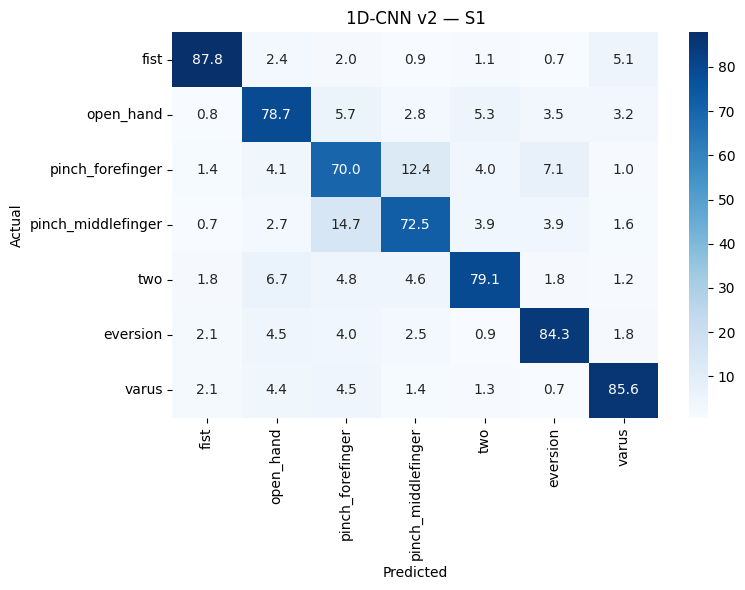

array([[3696,  100,   84,   37,   46,   30,  215],
       [  34, 3290,  239,  115,  220,  148,  133],
       [  59,  171, 2941,  520,  170,  300,   43],
       [  28,  113,  623, 3072,  167,  167,   69],
       [  74,  279,  201,  194, 3302,   74,   51],
       [  84,  181,  164,  102,   35, 3426,   72],
       [  87,  185,  189,   61,   53,   31, 3606]])

In [5]:
y_pred = predict(model_s1, X_test)
metrics_s1 = print_report(y_test, y_pred, title="1D-CNN v2 — S1 Ideal")
plot_confusion_matrix(y_test, y_pred, title="1D-CNN v2 — S1")

In [6]:
# Per-subject
subset = META[(META["session"] == 0) & (META["position"] == 0)]
per_subject_acc = {}
for subj in sorted(subset["subject"].unique()):
    subj_df = subset[subset["subject"] == subj]
    train_df = subj_df[subj_df["repetition"].isin([0, 1])]
    test_df = subj_df[subj_df["repetition"] == 2]
    X_tr, y_tr = load_windows_from_metadata(train_df, verbose=False)
    X_te, y_te = load_windows_from_metadata(test_df, verbose=False)
    mean, std = compute_normalization_stats(X_tr)
    X_tr = apply_normalization(X_tr, mean, std)
    X_te = apply_normalization(X_te, mean, std)
    m = TemporalSCNN().to(DEVICE)
    loader = make_loader(X_tr, y_tr, mixup=True, batch_size=128)
    train_model(m, loader, n_epochs=60, lr=3e-3)
    per_subject_acc[subj] = accuracy_score(y_te, predict(m, X_te))

accs = list(per_subject_acc.values())
print(f"\nPer-subject: mean={np.mean(accs):.4f}, min={np.min(accs):.4f}, max={np.max(accs):.4f}")
for subj, acc in sorted(per_subject_acc.items()):
    bar = "█" * int(acc * 40)
    print(f"  {subj:4s}: {acc:.3f} {bar}")

Epoch   1/60 — loss: 1.9413, acc: 0.1717
Epoch  10/60 — loss: 0.7831, acc: 0.8905
Epoch  20/60 — loss: 0.6409, acc: 0.9308
Epoch  30/60 — loss: 0.6349, acc: 0.9340
Epoch  40/60 — loss: 0.6242, acc: 0.9379
Epoch  50/60 — loss: 0.5963, acc: 0.9532
Epoch  60/60 — loss: 0.5907, acc: 0.9564
Epoch   1/60 — loss: 1.9555, acc: 0.1259
Epoch  10/60 — loss: 0.9372, acc: 0.8454
Epoch  20/60 — loss: 0.6472, acc: 0.9347
Epoch  30/60 — loss: 0.5857, acc: 0.9586
Epoch  40/60 — loss: 0.5658, acc: 0.9737
Epoch  50/60 — loss: 0.5317, acc: 0.9801
Epoch  60/60 — loss: 0.5465, acc: 0.9801
Epoch   1/60 — loss: 1.9235, acc: 0.2190
Epoch  10/60 — loss: 0.7154, acc: 0.9167
Epoch  20/60 — loss: 0.5796, acc: 0.9587
Epoch  30/60 — loss: 0.5411, acc: 0.9790
Epoch  40/60 — loss: 0.5272, acc: 0.9889
Epoch  50/60 — loss: 0.5307, acc: 0.9823
Epoch  60/60 — loss: 0.5182, acc: 0.9849
Epoch   1/60 — loss: 1.9430, acc: 0.1649
Epoch  10/60 — loss: 0.7213, acc: 0.9125
Epoch  20/60 — loss: 0.5878, acc: 0.9683
Epoch  30/60 — l

In [7]:
torch.save(model_s1.state_dict(), MODELS_DIR / "1dcnn_v2_s1.pt")
print("Saved.")

Saved.


---
## Scenario 2 — Electrode Shift (5 calibration positions + circular aug)

In [8]:
subset_s2 = META[(META["session"] == 0) & (META["subject"].isin(SUBJECTS_NON_FATIGUE))]

TRAIN_POS = [0, 2, 4, 6, 8]  # 5 positions, evenly spread
TEST_POS = [p for p in range(11) if p not in TRAIN_POS]
print(f"Train positions: {TRAIN_POS}")
print(f"Test positions:  {TEST_POS}")

train_df = subset_s2[subset_s2["position"].isin(TRAIN_POS)]
X_train_s2, y_train_s2 = load_windows_from_metadata(train_df)
mean_s2, std_s2 = compute_normalization_stats(X_train_s2)
X_train_s2 = apply_normalization(X_train_s2, mean_s2, std_s2)
print(f"Train raw: {X_train_s2.shape}")

X_s2_aug, y_s2_aug = circular_augment(X_train_s2, y_train_s2)
print(f"After aug: {X_s2_aug.shape[0]:,}")

Train positions: [0, 2, 4, 6, 8]
Test positions:  [1, 3, 5, 7, 9, 10]


Loading windows: 100%|██████████| 3146/3146 [00:01<00:00, 2645.06it/s]


Train raw: (357835, 8, 50)
After aug: 2,862,680


In [9]:
model_s2 = TemporalSCNN().to(DEVICE)
loader_s2 = make_loader(X_s2_aug, y_s2_aug, mixup=True)
train_model(model_s2, loader_s2, n_epochs=50)

Epoch   1/50 — loss: 1.5957, acc: 0.4231
Epoch  10/50 — loss: 1.2383, acc: 0.6313
Epoch  20/50 — loss: 1.2358, acc: 0.6328
Epoch  30/50 — loss: 1.1955, acc: 0.6534
Epoch  40/50 — loss: 1.1384, acc: 0.6830
Epoch  50/50 — loss: 1.0963, acc: 0.7046


In [10]:
acc_per_pos = {}
for pos in TEST_POS:
    pos_df = subset_s2[subset_s2["position"] == pos]
    X_p, y_p = load_windows_from_metadata(pos_df, verbose=False)
    X_p = apply_normalization(X_p, mean_s2, std_s2)
    acc_per_pos[pos] = accuracy_score(y_p, predict(model_s2, X_p))
    print(f"Position {pos:2d}: {acc_per_pos[pos]:.4f}")

avg_s2 = np.mean(list(acc_per_pos.values()))
print(f"\nS2 avg: {avg_s2:.4f}")

Position  1: 0.6803
Position  3: 0.7218
Position  5: 0.7291
Position  7: 0.7309
Position  9: 0.7096
Position 10: 0.6783

S2 avg: 0.7083


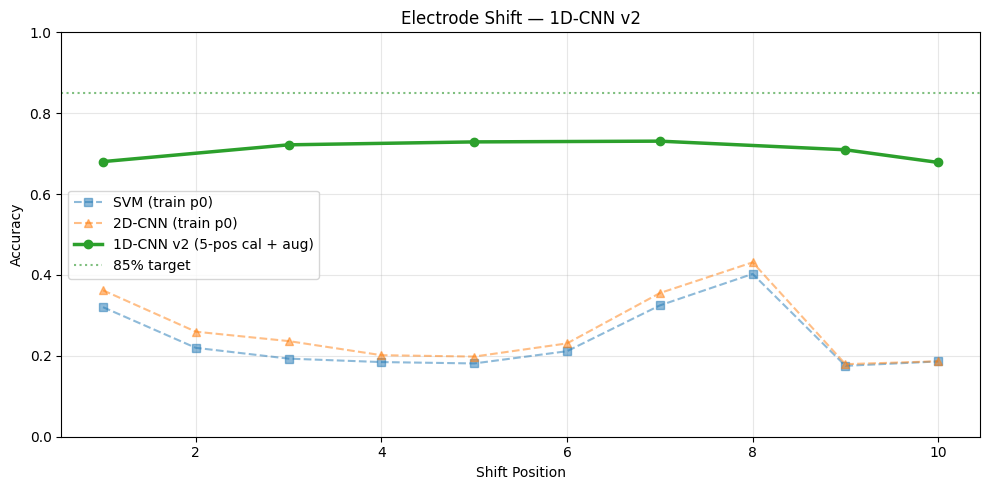

In [11]:
# Plot comparison
svm_s = [0.3203, 0.2198, 0.1931, 0.1846, 0.1812, 0.2115, 0.3247, 0.4026, 0.1753, 0.1862]
cnn_s = [0.3620, 0.2597, 0.2365, 0.2016, 0.1982, 0.2308, 0.3552, 0.4312, 0.1794, 0.1866]

plt.figure(figsize=(10, 5))
plt.plot(range(1,11), svm_s, "s--", label="SVM (train p0)", alpha=0.5)
plt.plot(range(1,11), cnn_s, "^--", label="2D-CNN (train p0)", alpha=0.5)
plt.plot(TEST_POS, [acc_per_pos[p] for p in TEST_POS], "o-", label="1D-CNN v2 (5-pos cal + aug)", linewidth=2.5)
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5, label="85% target")
plt.xlabel("Shift Position")
plt.ylabel("Accuracy")
plt.title("Electrode Shift — 1D-CNN v2")
plt.ylim(0, 1)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "1dcnn_v2_shift.png"), dpi=150)
plt.show()

In [12]:
torch.save(model_s2.state_dict(), MODELS_DIR / "1dcnn_v2_s2.pt")
print("Saved.")

Saved.


---
## Scenario 3 — Inter-Subject (ALL sessions from training subjects)

Key change: h0-h5 contribute 10 sessions each, h6-h13 contribute 3 each.
This gives the model much more diversity in how different people perform gestures across different days.

In [13]:
# Same test subjects as all previous experiments
rng = np.random.RandomState(RANDOM_SEED)
all_subjects = sorted(META[META["subject"].isin(SUBJECTS_NON_FATIGUE)]["subject"].unique())
test_subjects = list(rng.choice(all_subjects, size=6, replace=False))
train_subjects = [s for s in all_subjects if s not in test_subjects]
print(f"Train subjects: {train_subjects} ({len(train_subjects)})")
print(f"Test subjects:  {test_subjects}")

# Train: ALL sessions, ALL positions from training subjects
train_df_s3 = META[META["subject"].isin(train_subjects)]
# Test: session 0 only from test subjects (fair comparison with previous)
test_df_s3 = META[(META["subject"].isin(test_subjects)) & (META["session"] == 0)]

print(f"\nTrain trials: {len(train_df_s3)} (all sessions)")
print(f"Test trials:  {len(test_df_s3)} (session 0 only)")

X_train_s3, y_train_s3 = load_windows_from_metadata(train_df_s3)
X_test_s3, y_test_s3 = load_windows_from_metadata(test_df_s3)

mean_s3, std_s3 = compute_normalization_stats(X_train_s3)
X_train_s3 = apply_normalization(X_train_s3, mean_s3, std_s3)
X_test_s3 = apply_normalization(X_test_s3, mean_s3, std_s3)

print(f"Train windows: {X_train_s3.shape}")
print(f"Test windows:  {X_test_s3.shape}")

Train subjects: ['h0', 'h1', 'h10', 'h11', 'h12', 'h13', 'h14', 'h15', 'h18', 'h19', 'h2', 'h20', 'h21', 'h23', 'h25', 'h26', 'h27', 'h28', 'h29', 'h4', 'h5', 'h6', 'h8', 'h9'] (24)
Test subjects:  ['h7', 'h22', 'h3', 'h24', 'h16', 'h17']

Train trials: 19148 (all sessions)
Test trials:  1385 (session 0 only)


Loading windows: 100%|██████████| 1385/1385 [00:00<00:00, 2440.63it/s]


Train windows: (2107072, 8, 50)
Test windows:  (168232, 8, 50)


In [14]:
model_s3 = TemporalSCNN().to(DEVICE)
loader_s3 = make_loader(X_train_s3, y_train_s3, mixup=True)
train_model(model_s3, loader_s3, n_epochs=80, lr=3e-3)

Epoch   1/80 — loss: 1.6234, acc: 0.4043
Epoch  10/80 — loss: 1.1358, acc: 0.6838
Epoch  20/80 — loss: 1.1451, acc: 0.6799
Epoch  30/80 — loss: 1.1325, acc: 0.6864
Epoch  40/80 — loss: 1.1109, acc: 0.6972
Epoch  50/80 — loss: 1.0807, acc: 0.7124
Epoch  60/80 — loss: 1.0462, acc: 0.7295
Epoch  70/80 — loss: 1.0107, acc: 0.7475
Epoch  80/80 — loss: 0.9925, acc: 0.7566



  1D-CNN v2 — S3 Inter-Subject (all sessions)
  Accuracy:  0.5574
  F1-macro:  0.5517
                    precision    recall  f1-score   support

              fist       0.69      0.58      0.63     23888
         open_hand       0.50      0.59      0.54     23933
  pinch_forefinger       0.46      0.43      0.45     24284
pinch_middlefinger       0.54      0.35      0.42     24064
               two       0.58      0.54      0.56     23897
          eversion       0.55      0.80      0.65     24069
             varus       0.61      0.60      0.60     24097

          accuracy                           0.56    168232
         macro avg       0.56      0.56      0.55    168232
      weighted avg       0.56      0.56      0.55    168232



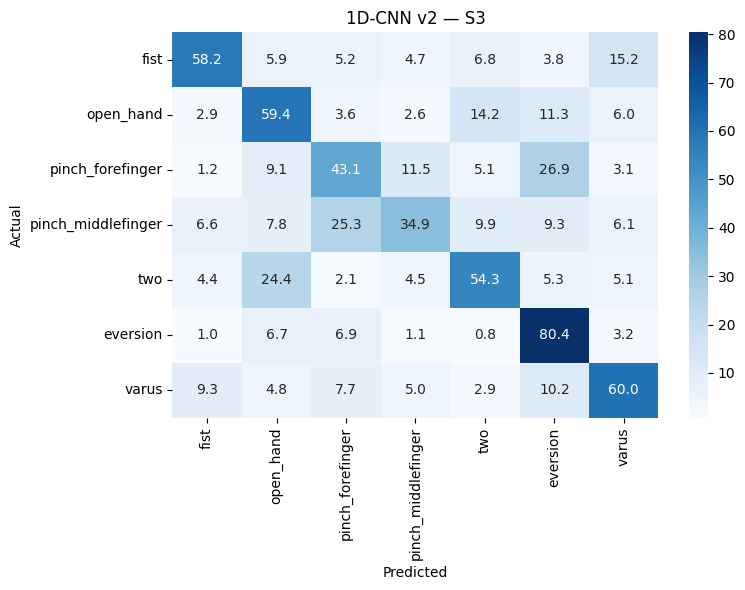

array([[13914,  1412,  1254,  1131,  1633,   904,  3640],
       [  690, 14228,   865,   621,  3397,  2704,  1428],
       [  303,  2214, 10464,  2799,  1237,  6526,   741],
       [ 1598,  1873,  6099,  8396,  2393,  2229,  1476],
       [ 1062,  5830,   493,  1065, 12969,  1269,  1209],
       [  246,  1613,  1651,   263,   186, 19343,   767],
       [ 2249,  1163,  1856,  1209,   690,  2467, 14463]])

In [15]:
y_pred_s3 = predict(model_s3, X_test_s3)
metrics_s3 = print_report(y_test_s3, y_pred_s3, title="1D-CNN v2 — S3 Inter-Subject (all sessions)")
plot_confusion_matrix(y_test_s3, y_pred_s3, title="1D-CNN v2 — S3")

In [16]:
torch.save(model_s3.state_dict(), MODELS_DIR / "1dcnn_v2_s3.pt")
print("Saved.")

Saved.


---
## Scenario 4 — Inter-Day

In [17]:
X_train_s4, y_train_s4, test_by_sess, info_s4 = scenario_4_interday()
print(f"Train: {X_train_s4.shape}")

model_s4 = TemporalSCNN().to(DEVICE)
loader_s4 = make_loader(X_train_s4, y_train_s4, mixup=True)
train_model(model_s4, loader_s4, n_epochs=60)

Loading windows: 100%|██████████| 126/126 [00:00<00:00, 2304.48it/s]


Train: (13445, 8, 50)
Epoch   1/60 — loss: 1.9068, acc: 0.2059
Epoch  10/60 — loss: 0.8526, acc: 0.8332
Epoch  20/60 — loss: 0.7061, acc: 0.9088
Epoch  30/60 — loss: 0.6592, acc: 0.9276
Epoch  40/60 — loss: 0.6218, acc: 0.9418
Epoch  50/60 — loss: 0.5977, acc: 0.9513
Epoch  60/60 — loss: 0.5948, acc: 0.9534


Session 1: 0.6037
Session 2: 0.7243
Session 3: 0.6603
Session 4: 0.6851
Session 5: 0.6189
Session 6: 0.7285
Session 7: 0.6322
Session 8: 0.7118
Session 9: 0.5797

S4 avg: 0.6605


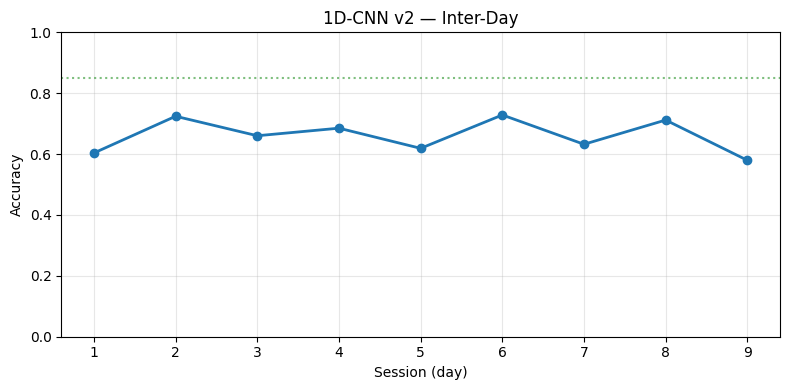

In [18]:
acc_per_sess = {}
for sess, (X_s, y_s) in sorted(test_by_sess.items()):
    acc_per_sess[sess] = accuracy_score(y_s, predict(model_s4, X_s))
    print(f"Session {sess}: {acc_per_sess[sess]:.4f}")

avg_s4 = np.mean(list(acc_per_sess.values()))
print(f"\nS4 avg: {avg_s4:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_sess.keys()), list(acc_per_sess.values()), "o-", linewidth=2)
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5)
plt.xlabel("Session (day)")
plt.ylabel("Accuracy")
plt.title("1D-CNN v2 — Inter-Day")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "1dcnn_v2_interday.png"), dpi=150)
plt.show()

---
## Scenario 5 — Fatigue

In [19]:
X_train_s5, y_train_s5, test_by_fatigue, info_s5 = scenario_5_fatigue()
print(f"Train: {X_train_s5.shape}")

model_s5 = TemporalSCNN().to(DEVICE)
loader_s5 = make_loader(X_train_s5, y_train_s5, mixup=True)
train_model(model_s5, loader_s5, n_epochs=60)

Loading windows: 100%|██████████| 252/252 [00:00<00:00, 1660.81it/s]


Train: (33046, 8, 50)
Epoch   1/60 — loss: 1.8169, acc: 0.3082
Epoch  10/60 — loss: 0.7792, acc: 0.8669
Epoch  20/60 — loss: 0.6834, acc: 0.9111
Epoch  30/60 — loss: 0.6493, acc: 0.9233
Epoch  40/60 — loss: 0.6326, acc: 0.9312
Epoch  50/60 — loss: 0.6023, acc: 0.9450
Epoch  60/60 — loss: 0.5955, acc: 0.9464


Position  2: 0.8954
Position  3: 0.8857
Position  4: 0.8952
Position  5: 0.8965
Position  6: 0.8828
Position  7: 0.9032
Position  8: 0.8544
Position  9: 0.8767
Position 10: 0.8483

S5 avg: 0.8820


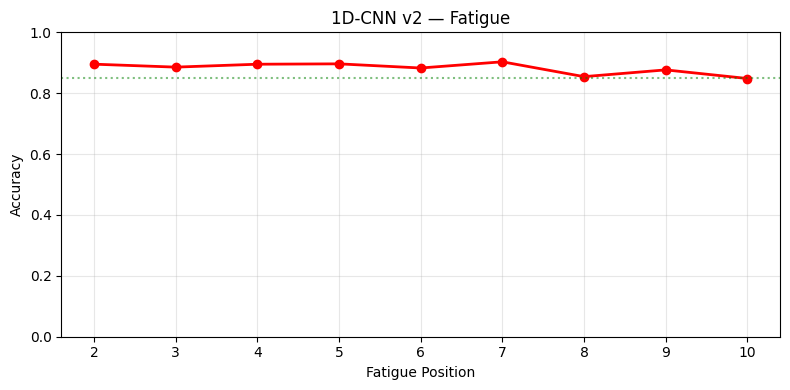

In [20]:
acc_per_fat = {}
for pos, (X_p, y_p) in sorted(test_by_fatigue.items()):
    acc_per_fat[pos] = accuracy_score(y_p, predict(model_s5, X_p))
    print(f"Position {pos:2d}: {acc_per_fat[pos]:.4f}")

avg_s5 = np.mean(list(acc_per_fat.values()))
print(f"\nS5 avg: {avg_s5:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(list(acc_per_fat.keys()), list(acc_per_fat.values()), "o-", linewidth=2, color="red")
plt.axhline(y=0.85, color="green", ls=":", alpha=0.5)
plt.xlabel("Fatigue Position")
plt.ylabel("Accuracy")
plt.title("1D-CNN v2 — Fatigue")
plt.ylim(0, 1)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(str(PROJECT_ROOT / "results" / "figures" / "1dcnn_v2_fatigue.png"), dpi=150)
plt.show()

---
## Latency

In [21]:
model_s1.eval()
sample = torch.randn(1, 8, 50).to(DEVICE)
for _ in range(10):
    _ = model_s1(sample)
if DEVICE.type == "mps":
    torch.mps.synchronize()

def predict_single(x):
    x_t = torch.from_numpy(x).float().to(DEVICE)
    with torch.no_grad():
        out = model_s1(x_t)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    return out.argmax(1).cpu().numpy()

sample_np = np.random.randn(1, 8, 50).astype(np.float32)
latency = measure_latency(predict_single, sample_np, n_runs=500)
print_latency(latency, model_name="1D-CNN v2")
print(f"Parameters: {sum(p.numel() for p in model_s1.parameters()):,}")


Latency — 1D-CNN v2
  Mean:   2.82 ms
  Median: 2.90 ms
  P95:    3.14 ms
  <300ms: ✓
Parameters: 62,676


---
## Full Comparison

In [22]:
n_params = sum(p.numel() for p in model_s1.parameters())

print("\n" + "=" * 80)
print("FULL COMPARISON — ALL METHODS")
print("=" * 80)
print(f"{'Metric':<22} {'SVM':>8} {'2D-CNN':>8} {'SCNN-ECA':>8} {'1D-v1':>8} {'1D-v2':>8}")
print("-" * 80)
print(f"{'S1 Ideal':<22} {'65.19%':>8} {'75.78%':>8} {'76.32%':>8} {'79.99%':>8} {metrics_s1['accuracy']*100:>7.2f}%")
print(f"{'S1 Per-subj':<22} {'77.70%':>8} {'—':>8} {'81.75%':>8} {'81.06%':>8} {np.mean(accs)*100:>7.2f}%")
print(f"{'S2 Shift (cal)':<22} {'23.99%':>8} {'26.41%':>8} {'57.18%':>8} {'65.65%':>8} {avg_s2*100:>7.2f}%")
print(f"{'S3 Inter-subject':<22} {'40.27%':>8} {'52.90%':>8} {'51.15%':>8} {'50.44%':>8} {metrics_s3['accuracy']*100:>7.2f}%")
print(f"{'S4 Inter-day':<22} {'63.03%':>8} {'67.30%':>8} {'61.22%':>8} {'67.55%':>8} {avg_s4*100:>7.2f}%")
print(f"{'S5 Fatigue':<22} {'81.20%':>8} {'86.98%':>8} {'85.10%':>8} {'87.29%':>8} {avg_s5*100:>7.2f}%")
print(f"{'Latency p95 (ms)':<22} {'5.40':>8} {'1.74':>8} {'1.47':>8} {'3.03':>8} {latency['p95_ms']:>7.2f}")
print(f"{'Parameters':<22} {'—':>8} {'101,831':>8} {'44,764':>8} {'62,676':>8} {n_params:>8,}")
print("=" * 80)
print(f"\nNotes:")
print(f"  S2: SVM/2D-CNN train p0 only. SCNN-ECA train p0,p3,p6. 1D-CNN v2 train p0,p2,p4,p6,p8.")
print(f"  S3: 1D-CNN v2 uses ALL sessions from training subjects (not just session 0).")


FULL COMPARISON — ALL METHODS
Metric                      SVM   2D-CNN SCNN-ECA    1D-v1    1D-v2
--------------------------------------------------------------------------------
S1 Ideal                 65.19%   75.78%   76.32%   79.99%   79.69%
S1 Per-subj              77.70%        —   81.75%   81.06%   81.24%
S2 Shift (cal)           23.99%   26.41%   57.18%   65.65%   70.83%
S3 Inter-subject         40.27%   52.90%   51.15%   50.44%   55.74%
S4 Inter-day             63.03%   67.30%   61.22%   67.55%   66.05%
S5 Fatigue               81.20%   86.98%   85.10%   87.29%   88.20%
Latency p95 (ms)           5.40     1.74     1.47     3.03    3.14
Parameters                    —  101,831   44,764   62,676   62,676

Notes:
  S2: SVM/2D-CNN train p0 only. SCNN-ECA train p0,p3,p6. 1D-CNN v2 train p0,p2,p4,p6,p8.
  S3: 1D-CNN v2 uses ALL sessions from training subjects (not just session 0).
